# Complementary filter

Conceptually, sensor fusion consists on estimating a magnitude levering data from different sensors. In this case, the magnitudes of interest are roll and pitch, which will be later used to remove gravity from linear acceleration by trasforming the g vector to the device's reference frame and substracting it. 

The complementary filter is a simple way to do this, based on different characteristics of the sensors:

* Gyroscope: good short-term stability, but drifts in the long term.
* Accelerometer: good long-term stability, but noisy in the short term.

On continuous time the idea would be to apply a low-pass effect on angle the computed from accelerometer data and a high-pass effect on the integrated gyroscope data. On discrete time, this can be implemented with the following formula:

$$
\theta_t = \alpha (\theta_{t-1} + \omega_{t} \cdot \Delta t) + (1 - \alpha) \theta_{acc, t}
$$

Where $0 < \alpha \leq 1$ is a tuning parameter, and: $\alpha = \frac{\tau}{\tau + \Delta t}$, where $\tau$ is the time constant of the filter and $\Delta t$ is the sampling period.

In 3D space, considering the FLU (forwards, left, up) system of coordinates shown in the figure below:

<img src="../../docs/misc/roll-pitch-yaw.webp" alt="Coordinate system" width="250" height="250">

where for the device at rest and with no other forces acting on it aside from gravity: 

  $$
    a_{x} = - g \cdot sin\ \theta_{acc, pitch}
  $$

  $$
  a_{y} = g \cdot sin\ \theta_{acc, roll} \cdot cos\ \theta_{acc, pitch}
  $$
  
  $$
  a_{z} = g \cdot cos\ \theta_{acc, roll} \cdot cos\ \theta_{acc, pitch}
  $$

Angles from the accelerometer can be computed with the following formulas:

  $$
    \theta_{acc, roll} = arctan(\frac{a_{y}}{a_{z}})
  $$

  $$
    \theta_{acc, pitch} = arctan(\frac{-a_{x}}{\sqrt{a_{y}^2 + a_{z}^2}})
  $$

  Note: within this notebook, use *atan2* instead of *atan* to compute the angles, since it preserves the cuadrant of the angle when both arguments carry a sign.

Notice that $\theta_{acc, yaw}$ can't be computed from the accelerometer data, since the rotation around the gravity vector is unobservable from acceleration.  Another point of reference, such as a magnetometer, would be needed to compute this angle. As a consequence, the complementary filter can only be applied to roll and pitch angles, while the yaw angle can only be computed from the gyroscope data. However, since common calisthenics movements happen mostly on the sagital plane and a minor set on the frontal plane of the human body, the XY plane can be oriented to correspond with the plane of least importance, i.e. the transverse plane. As a reference, the following figure shows the three planes of movement of the human body: 

<img src="../../docs/misc/planes-of-motion-human-body.webp" alt="Coordinate system" width="400" height="300">
 
Since the mounted sensor on the first prototype is not actually in the coordinate system shown in the figure above, but with the +x axis pointing to the right, +y axis pointing down, and +z axis pointing forwards, the frame has to be transformed through software with a linear transformation:

$$
\boldsymbol{a}_{software}
=
\begin{bmatrix}
0 & 0 & 1 \\
-1 & 0 & 0 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\boldsymbol{a}_{hardware}
$$

$$
\boldsymbol{\omega}_{software}
=
\begin{bmatrix}
0 & 0 & 1 \\
-1 & 0 & 0 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\boldsymbol{\omega}_{hardware}
$$
or more simply,
$$
\boldsymbol{a}_{x, software} = \boldsymbol{a}_{z, hardware} \newline
\boldsymbol{a}_{y, software} = -\boldsymbol{a}_{x, hardware} \newline
\boldsymbol{a}_{z, software} = -\boldsymbol{a}_{y, hardware}
$$
$$
\boldsymbol{\omega}_{roll, software} = \boldsymbol{\omega}_{yaw, hardware} \newline
\boldsymbol{\omega}_{pitch, software} = -\boldsymbol{\omega}_{roll, hardware} \newline
\boldsymbol{\omega}_{yaw, software} = -\boldsymbol{\omega}_{pitch, hardware}



$$




Additionally, the formulas assume that gravity is the only force acting on the device, but that is not the case in this application. A possible solution could involve changing alpha to favor the gyroscope data more heavily when the device is in motion, and weigh the accelerometer more when the device is relatively stationary. A simple (but not perfect) way to detect motion is to check that: $ | ||\mathbf{a}|| - g | > tol $, where *tol* is a tolerance value that can be tuned.  

Sources:

* ["The balance filter" by Shane Colton](../../docs/misc/Motion%20filters.pdf)

* ["Using an Accelerometer for inclination sensing" application note by Christopher Fisher](../../docs/misc/Accelerometer%20inclination.pdf)

* [Drone Control and the Complementary Filter by Brian Douglas](https://www.youtube.com/watch?v=whSw42XddsU)


## Setup

In [330]:
from signal_utils import IMUSampleReader, IMUSampleTimeSeriesPlotter
import matplotlib.pyplot as plt
import numpy as np
import math
from statistics import fmean, pstdev

# CAPTURE_PATH = "../exercise-reception/capture-apr-28-2026/pull-ups-1.csv"
# CAPTURE_PATH = "../1-calibration/output/positive-z-up-calibrated.csv"

# CAPTURE_PATH = "./capture/rotation-x-hw.csv"
# CAPTURE_PATH = "./capture/rotation-y-hw.csv"
CAPTURE_PATH = "./capture/rotation-z-hw.csv"

reader = IMUSampleReader()
samples = reader.read(CAPTURE_PATH)

rawSamplestimeSeriesPlotter = IMUSampleTimeSeriesPlotter()

## Transform frame

In [331]:
axHw = np.array(samples["a"]["x"])
ayHw = np.array(samples["a"]["y"])
azHw = np.array(samples["a"]["z"])
samples["a"]["x"] = azHw
samples["a"]["y"] = -1 * axHw
samples["a"]["z"] = -1 * ayHw

rollHw = np.array(samples["w"]["roll"])
pitchHw = np.array(samples["w"]["pitch"])
yawHw = np.array(samples["w"]["yaw"])
samples["w"]["roll"] = yawHw
samples["w"]["pitch"] = -1 * rollHw
samples["w"]["yaw"] = -1 * pitchHw

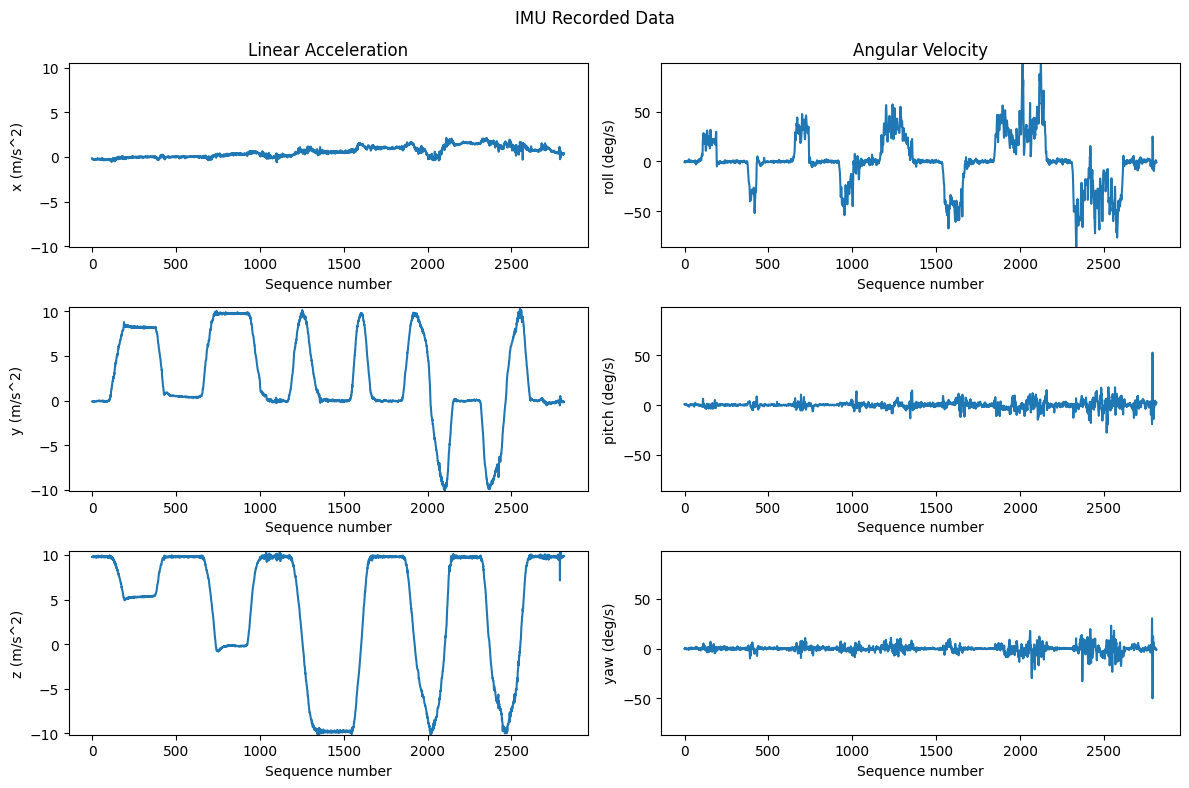

In [332]:
rawSamplestimeSeriesPlotter.plot(samples)

## Angles estimation from accelerometer data

In [333]:
# computeRollAngleAccel = (
#     lambda ax, ay, az: 180 / np.pi * math.atan2(ay, math.sqrt(ax**2 + az**2))
# )
# computePitchAngleAccel = (
#     lambda ax, ay, az: 180 / np.pi * math.atan2(ax, math.sqrt(ay**2 + az**2))
# )

computeRollAngleAccel = lambda ax, ay, az: 180 / np.pi * math.atan2(ay, az)
computePitchAngleAccel = (
    lambda ax, ay, az: 180 / np.pi * math.atan2(-ax, math.sqrt(ay**2 + az**2))
)

rollAngleAccel = np.array([computeRollAngleAccel(ax, ay, az) for ax, ay, az in zip(samples["a"]["x"], samples["a"]["y"], samples["a"]["z"])])  # type: ignore
pitchAngleAccel = np.array([computePitchAngleAccel(ax, ay, az) for ax, ay, az in zip(samples["a"]["x"], samples["a"]["y"], samples["a"]["z"])])  # type: ignore

## Angles estimation from gyroscope data

In [334]:
SAMPLING_FREQUENCY = 30  # Hz
dt = 1 / SAMPLING_FREQUENCY

integrateEuler = lambda prev, slope, step: prev + slope * step

signalLength = len(samples["w"]["roll"])  # type: ignore
rollAngleGyro = np.zeros(signalLength)  # type: ignore
pitchAngleGyro = np.zeros(signalLength)  # type: ignore
yawAngleGyro = np.zeros(signalLength)  # type: ignore
for i in range(1, signalLength):  # type: ignore
    rollAngleGyro[i] = integrateEuler(rollAngleGyro[i - 1], samples["w"]["roll"][i], dt)  # type: ignore
    pitchAngleGyro[i] = integrateEuler(pitchAngleGyro[i - 1], samples["w"]["pitch"][i], dt)  # type: ignore
    yawAngleGyro[i] = integrateEuler(yawAngleGyro[i - 1], samples["w"]["yaw"][i], dt)  # type: ignore

## Complementary filter

In [335]:
calibratedStationaryCapturesPaths = [
    "../1-calibration/output/positive-x-up-calibrated.csv",
    "../1-calibration/output/negative-x-up-calibrated.csv",
    "../1-calibration/output/positive-y-up-calibrated.csv",
    "../1-calibration/output/negative-y-up-calibrated.csv",
    "../1-calibration/output/positive-z-up-calibrated.csv",
    "../1-calibration/output/negative-z-up-calibrated.csv",
]
accelNorms = np.array([])
for path in calibratedStationaryCapturesPaths:
    stationarySamples = reader.read(path)
    ax = np.array(stationarySamples["a"]["x"])
    ay = np.array(stationarySamples["a"]["y"])
    az = np.array(stationarySamples["a"]["z"])
    accelNorms = np.append(accelNorms, np.sqrt(ax**2 + ay**2 + az**2))
accelNormsMean = fmean(accelNorms)
accelNormsStdev = pstdev(accelNorms)
tol = 1.5 * accelNormsStdev
print(
    f"Accel norms: mean={accelNormsMean:.6f}, stdev={accelNormsStdev:.6f}\nStationary tol = {tol:.6f}"
)

Accel norms: mean=9.806204, stdev=0.040047
Stationary tol = 0.060070


In [336]:
g = 9.81
alpha = 0.99
rollAngleCompl = np.zeros(signalLength)  # type: ignore
pitchAngleCompl = np.zeros(signalLength)  # type: ignore
for i in range(1, signalLength):  # type: ignore
    ax = samples["a"]["x"][i]  # type: ignore
    ay = samples["a"]["y"][i]  # type: ignore
    az = samples["a"]["z"][i]  # type: ignore
    if abs(math.sqrt(ax**2 + ay**2 + az**2) - g) < tol:
        rollAngleCompl[i] = alpha * (rollAngleCompl[i - 1] + samples["w"]["roll"][i] * dt) + (1 - alpha) * rollAngleAccel[i]  # type: ignore
        pitchAngleCompl[i] = alpha * (pitchAngleCompl[i - 1] + samples["w"]["pitch"][i] * dt) + (1 - alpha) * pitchAngleAccel[i]  # type: ignore
    else:
        rollAngleCompl[i] = rollAngleCompl[i - 1] + samples["w"]["roll"][i] * dt  # type: ignore
        pitchAngleCompl[i] = pitchAngleCompl[i - 1] + samples["w"]["pitch"][i] * dt  # type: ignore

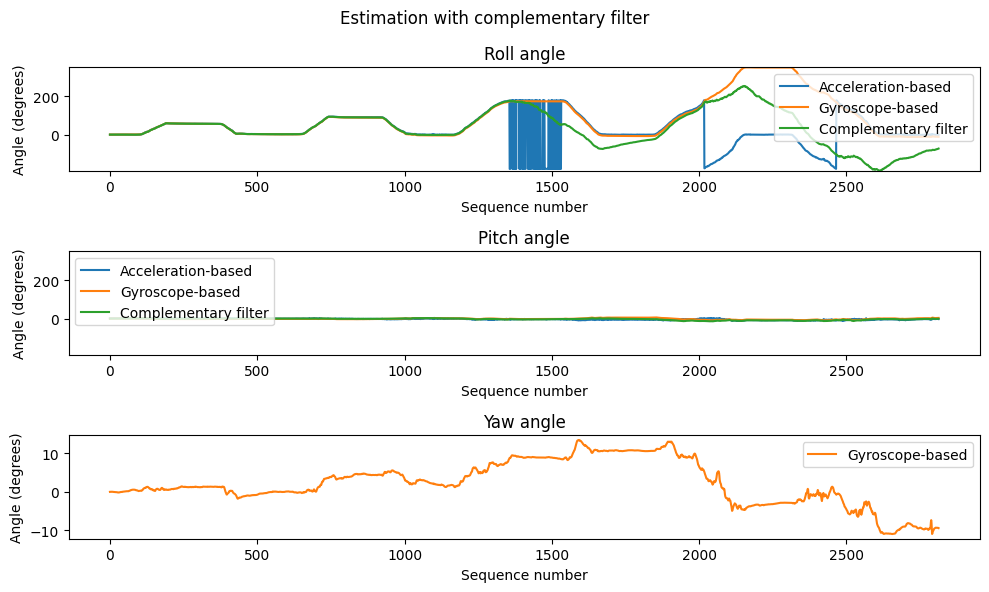

In [337]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6))

fig.suptitle("Estimation with complementary filter")

lowerBoundAngle = min(min(rollAngleAccel), min(pitchAngleAccel), min(rollAngleGyro), min(pitchAngleGyro), min(yawAngleGyro), min(rollAngleCompl), min(pitchAngleCompl))  # type: ignore
upperBoundAngle = max(max(rollAngleAccel), max(pitchAngleAccel), max(rollAngleGyro), max(pitchAngleGyro), max(yawAngleGyro), max(rollAngleCompl), max(pitchAngleCompl))  # type: ignore

axes[0].plot(samples["seq"], rollAngleAccel, label="Acceleration-based")
axes[0].plot(samples["seq"], rollAngleGyro, label="Gyroscope-based")
axes[0].plot(samples["seq"], rollAngleCompl, label="Complementary filter")
axes[0].set_ylabel("Angle (degrees)")
axes[0].set_ylim(lowerBoundAngle, upperBoundAngle)
axes[0].set_xlabel("Sequence number")
axes[0].set_title("Roll angle")
axes[0].legend()

axes[1].plot(samples["seq"], pitchAngleAccel, label="Acceleration-based")
axes[1].plot(samples["seq"], pitchAngleGyro, label="Gyroscope-based")
axes[1].plot(samples["seq"], pitchAngleCompl, label="Complementary filter")
axes[1].set_ylabel("Angle (degrees)")
axes[1].set_ylim(lowerBoundAngle, upperBoundAngle)
axes[1].set_xlabel("Sequence number")
axes[1].set_title("Pitch angle")
axes[1].legend()

axes[2].plot(samples["seq"], yawAngleGyro, label="Gyroscope-based", color="#ff7f0e")
axes[2].set_ylabel("Angle (degrees)")
axes[2].set_xlabel("Sequence number")
axes[2].set_title("Yaw angle")
axes[2].legend()

plt.tight_layout()
plt.show()